# Disaster Tweet Classification using NLP

## Objective
To build a machine learning model that classifies tweets as disaster-related or not.

## Problem Statement

Social media platforms like Twitter provide real-time updates during disasters. However, many tweets use disaster-related words metaphorically.

This project aims to classify tweets into:
- Disaster Tweets (1)
- Non-Disaster Tweets (0)

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import *

## Loading Dataset

In [3]:
df = pd.read_csv("../data/twitter_disaster.csv")
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [ ]:
df.head()

## Data Exploration (EDA)

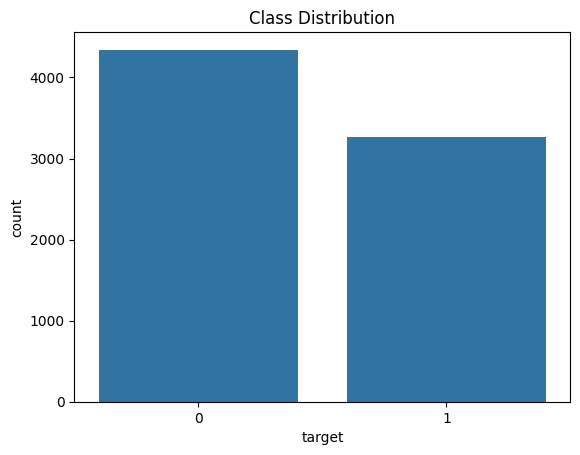

In [5]:
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

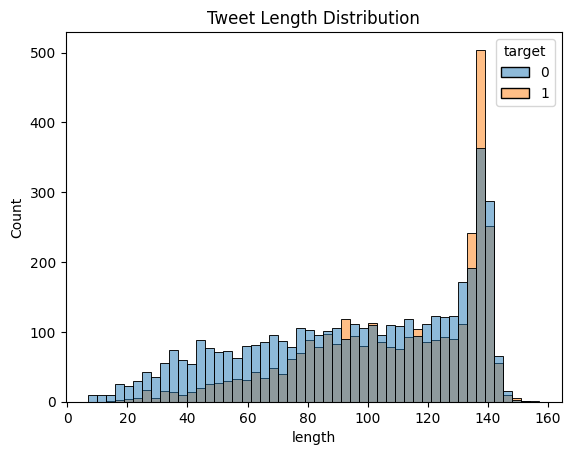

In [6]:
df['length'] = df['text'].apply(len)

sns.histplot(data=df, x='length', hue='target', bins=50)
plt.title("Tweet Length Distribution")
plt.show()

In [7]:
from collections import Counter

disaster_words = " ".join(df[df['target']==1]['text']).split()
non_disaster_words = " ".join(df[df['target']==0]['text']).split()

print("Top Disaster Words:", Counter(disaster_words).most_common(10))
print("Top Non-Disaster Words:", Counter(non_disaster_words).most_common(10))

Top Disaster Words: [('the', 1051), ('in', 1037), ('of', 888), ('a', 730), ('to', 706), ('and', 462), ('-', 389), ('on', 386), ('for', 368), ('is', 302)]
Top Non-Disaster Words: [('the', 1524), ('a', 1115), ('to', 1099), ('I', 938), ('and', 840), ('of', 834), ('in', 720), ('you', 529), ('is', 512), ('for', 452)]


## Data Preprocessing

In this project, text preprocessing is handled using a modular approach by importing functions from the `src/preprocess.py` file.

The preprocessing pipeline includes:

- Converting text to lowercase
- Removing URLs
- Removing special characters
- Tokenization
- Stopword removal
- Lemmatization

This ensures clean and meaningful text data for model training and improves overall performance.

In [8]:
import sys
import os

# Add src folder to path
sys.path.append(os.path.abspath("../src"))

from preprocess import clean_text

print("Applying advanced preprocessing from src/preprocess.py...")

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nehap\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nehap\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Applying advanced preprocessing from src/preprocess.py...


,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive u
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...


In [22]:
# --------- ADDITIONAL FEATURES ---------

df['tweet_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['hashtag_count'] = df['text'].apply(lambda x: x.count('#'))
df['mention_count'] = df['text'].apply(lambda x: x.count('@'))

### Preprocessing Verification

The cleaned text column shows the transformed version of raw tweets after applying preprocessing techniques.

This step ensures that noise such as URLs, punctuation, and stopwords are removed, and words are normalized using lemmatization.

In [9]:
print("Sample Cleaned Text:\n")
print(df['clean_text'].iloc[0])

Sample Cleaned Text:

deed reason earthquake may allah forgive u


In [10]:
print("Sample Cleaned Text:\n")
print(df['clean_text'].iloc[0])

Sample Cleaned Text:

deed reason earthquake may allah forgive u


## Feature Engineering

Text data is converted into numerical form using TF-IDF (Term Frequency-Inverse Document Frequency).

- Captures importance of words
- Uses unigrams and bigrams (n-grams)
- Limits features to top 10,000 words

This helps the model understand textual patterns effectively.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X_text = vectorizer.fit_transform(df['clean_text'])

In [24]:
from scipy.sparse import hstack

extra_features = df[['tweet_length', 'word_count', 'hashtag_count', 'mention_count']].values

X = hstack((X_text, extra_features))

y = df['target']

## Splitting Dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

Multiple machine learning models are trained:

- Logistic Regression
- Naive Bayes

Their performance is compared to select the best model.

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)


Logistic Regression
Accuracy: 0.7951411687458962

Naive Bayes
Accuracy: 0.7964543663821405


In [14]:
pd.DataFrame(results.items(), columns=["Model", "Accuracy"])

,Model,Accuracy
0,Logistic Regression,0.795141
1,Naive Bayes,0.796454


## Hyperparameter Tuning

In [15]:
params = {"C": [0.1, 1, 10]}

grid = GridSearchCV(LogisticRegression(max_iter=1000), params)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

## Model Evaluation

In [16]:
preds = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.7951411687458962
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       874
           1       0.81      0.67      0.74       649

    accuracy                           0.80      1523
   macro avg       0.80      0.78      0.78      1523
weighted avg       0.80      0.80      0.79      1523



## Why Precision and Recall Matter

In disaster detection:

- High Precision ensures predicted disasters are actually real  
- High Recall ensures real disasters are not missed  

This is important because missing a real disaster can be dangerous, while false alarms can create panic.

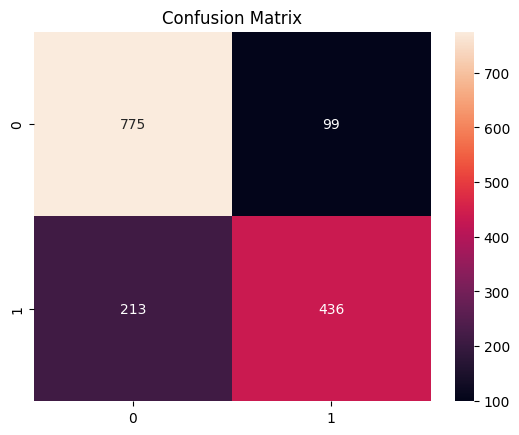

In [17]:
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

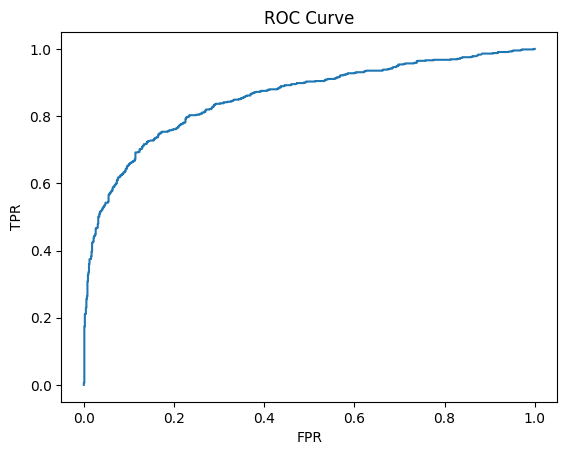

In [18]:
probs = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

## Error Analysis

In [19]:
errors = df.iloc[y_test.index][preds != y_test]
errors[['text','target']].head()

,text,target
2644,So you have a new weapon that can cause un-ima...,1
1765,my favorite lady came to our volunteer meeting...,1
1817,@brianroemmele UX fail of EMV - people want to...,1
4019,Who is bringing the tornadoes and floods. Who ...,0
1174,@BloopAndABlast Because I need to know if I'm ...,0


## Model Saving

The trained model and vectorizer are saved using Pickle.

This allows reuse without retraining and enables deployment in real-world applications.

In [20]:
import pickle

pickle.dump(best_model, open("../models/best_model.pkl", "wb"))
pickle.dump(vectorizer, open("../models/vectorizer.pkl", "wb"))

## Conclusion

The model successfully classifies disaster tweets.

Logistic Regression performed best after tuning.

The model achieves good accuracy, precision, and recall, making it suitable for real-world disaster detection.